In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('expense.csv')


In [4]:
df

,Date,Category,Description,Amount
0,08-07-2026,Transportation,Lyft,24.78
1,08-15-2026,Food,Ubereats,25.41
2,08-03-2026,Entertainment,Cineplex,16.00
3,08-04-2026,Entertainment,Netflix subscription,24.54
4,08-10-2026,Shopping,Personal care,55.00
5,08-15-2026,Transportation,Uber,16.00
6,08-20-2026,Food,Grocery,70.00
7,08-02-2026,Shopping,Clothes,100.21
8,08-17-2026,School,School supplies,50.00
9,08-17-2026,Transportation,Bus pass,50.45


In [5]:
df.head()


,Date,Category,Description,Amount
0,08-07-2026,Transportation,Lyft,24.78
1,08-15-2026,Food,Ubereats,25.41
2,08-03-2026,Entertainment,Cineplex,16.00
3,08-04-2026,Entertainment,Netflix subscription,24.54
4,08-10-2026,Shopping,Personal care,55.00


In [6]:
df.tail()

,Date,Category,Description,Amount
55,06-01-2027,Rent,Apartment,600.0
56,06-19-2027,Utilities,Hydro,50.0
57,06-10-2027,Entertainment,Ticket fee,45.0
58,06-18-2027,Entertainment,Dinner,30.0
59,06-18-2027,Transportation,Uber,35.0


In [7]:
df.columns

Index(['Date', 'Category', 'Description', 'Amount'], dtype='str')

In [8]:
df['Amount']

0      24.78
1      25.41
2      16.00
3      24.54
4      55.00
5      16.00
6      70.00
7     100.21
8      50.00
9      50.45
10    600.00
11    600.00
12     60.00
13    100.59
14     50.68
15     45.00
16    100.00
17     70.00
18     50.00
19     30.00
20     25.00
21     38.79
22    600.00
23     20.83
24     10.49
25     90.00
26      5.59
27    600.00
28    600.00
29    200.00
30    200.00
31     50.00
32     40.00
33    350.00
34    150.00
35     40.00
36    100.00
37     80.00
38    600.00
39    600.00
40     60.00
41     70.00
42    100.00
43     20.00
44     30.00
45     70.00
46     24.99
47    600.00
48     60.00
49     70.00
50     50.00
51    600.00
52     40.00
53     40.00
54    235.00
55    600.00
56     50.00
57     45.00
58     30.00
59     35.00
Name: Amount, dtype: float64

In [9]:
df['Amount'].sum()

np.float64(9369.35)

In [10]:
df['Amount'].mean()

np.float64(156.15583333333333)

In [11]:
df['Amount'].min()

np.float64(5.59)

In [12]:
df['Amount'].max()

np.float64(600.0)

In [13]:
category_totals = df.groupby('Category')['Amount'].sum()

In [14]:
category_totals

Category
Entertainment      365.53
Food               701.00
Rent              6000.00
School             185.59
Shopping           784.68
Transportation     772.55
Utilities          560.00
Name: Amount, dtype: float64

In [15]:
df.groupby('Category').size()

Category
Entertainment      9
Food               8
Rent              10
School             4
Shopping          10
Transportation     9
Utilities         10
dtype: int64

In [16]:
import matplotlib.pyplot as plt

PLOT BAR CHART TO VIEW SPENDING BY CATEGORY

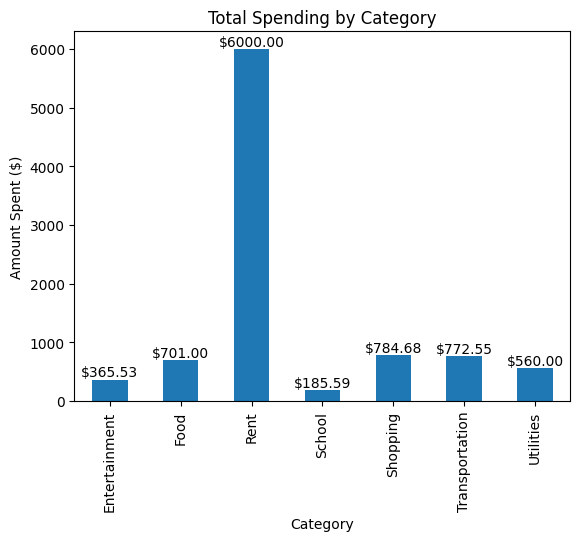

In [17]:
ax = category_totals.plot(kind='bar')

plt.title('Total Spending by Category')
plt.xlabel('Category')
plt.ylabel('Amount Spent ($)')

for i, value in enumerate(category_totals):
    ax.text(i, value, f'${value:.2f}', ha='center', va='bottom')

plt.show()

PLOT PIE CHART TO VIEW SPENDING BY CATEGORY

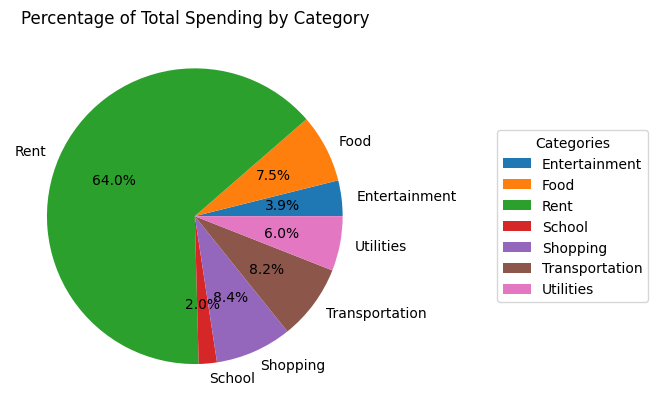

In [18]:
category_totals.plot(kind='pie', autopct='%1.1f%%')

plt.title('Percentage of Total Spending by Category')
plt.ylabel('')

plt.legend(
           title='Categories',
           bbox_to_anchor=(1.3,0.5),
           loc='center left')

plt.show()

In [19]:
df['Date'].dtype

<StringDtype(storage='python', na_value=nan)>

In [20]:
df['Date'] = pd.to_datetime(df['Date'])

In [21]:
df['Date'].dtype

dtype('<M8[us]')

In [22]:
daily_spending = df.groupby('Date')['Amount'].sum()

In [23]:
daily_spending

Date
2026-08-02    100.21
2026-08-03     16.00
2026-08-04     24.54
2026-08-07     24.78
2026-08-10     55.00
2026-08-15     41.41
2026-08-17    100.45
2026-08-20     70.00
2026-09-01    600.00
2026-09-06     90.00
2026-09-08    100.59
2026-09-10     50.00
2026-09-15     50.68
2026-10-02    600.00
2026-10-04     10.49
2026-10-05     70.00
2026-10-16     30.00
2026-10-23     25.00
2026-10-24     38.79
2026-10-25      5.59
2026-11-01    660.00
2026-11-08     45.00
2026-11-25     20.83
2026-11-28    100.00
2026-12-01    600.00
2026-12-16    200.00
2026-12-19     50.00
2026-12-24    200.00
2026-12-25    100.00
2027-01-02    600.00
2027-01-07    150.00
2027-01-09     40.00
2027-01-19     40.00
2027-01-20    350.00
2027-02-01    600.00
2027-02-09     80.00
2027-02-19     60.00
2027-02-20     70.00
2027-02-26     30.00
2027-03-01    600.00
2027-03-05     24.99
2027-03-10    100.00
2027-03-17     20.00
2027-03-19     70.00
2027-04-01    600.00
2027-04-10     60.00
2027-04-19     70.00
2027-04-

In [24]:
daily_spending.max()

np.float64(660.0)

In [25]:
daily_spending.loc[daily_spending.idxmax()]

np.float64(660.0)

In [26]:
df['Month'] = df['Date'].dt.month

In [27]:
df.head()

,Date,Category,Description,Amount,Month
0,2026-08-07,Transportation,Lyft,24.78,8
1,2026-08-15,Food,Ubereats,25.41,8
2,2026-08-03,Entertainment,Cineplex,16.00,8
3,2026-08-04,Entertainment,Netflix subscription,24.54,8
4,2026-08-10,Shopping,Personal care,55.00,8


In [28]:
monthly_totals = df.groupby('Month')['Amount'].sum()

In [29]:
month_order = [8,9,10,11,12,1,2,3,4,5,6]

monthly_totals = monthly_totals.reindex(month_order)

monthly_totals

Month
8      432.39
9      891.27
10     779.87
11     825.83
12    1150.00
1     1180.00
2      840.00
3      814.99
4      780.00
5      915.00
6      760.00
Name: Amount, dtype: float64

PLOT BAR GRAPH TO VIEW MONTHLY SPENDING

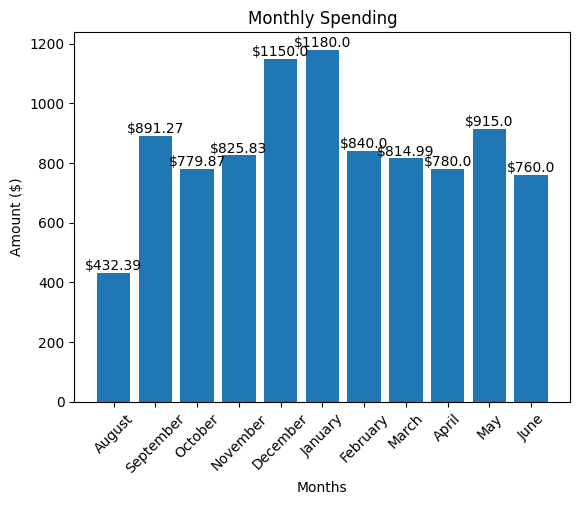

In [30]:
bars = plt.bar(range(len(monthly_totals)), monthly_totals.values)
labels = []
for amount in monthly_totals.values:
     label = f'${amount}'
     labels.append(label)

plt.bar_label(bars,labels)

plt.title('Monthly Spending')
plt.xlabel('Months')
plt.ylabel('Amount ($)')

plt.xticks(range(len(monthly_totals)),['August','September','October','November','December','January','February','March','April','May','June'],rotation=45)

plt.show()

PLOT LINE GRAPH TO VIEW MONTHLY SPENDING

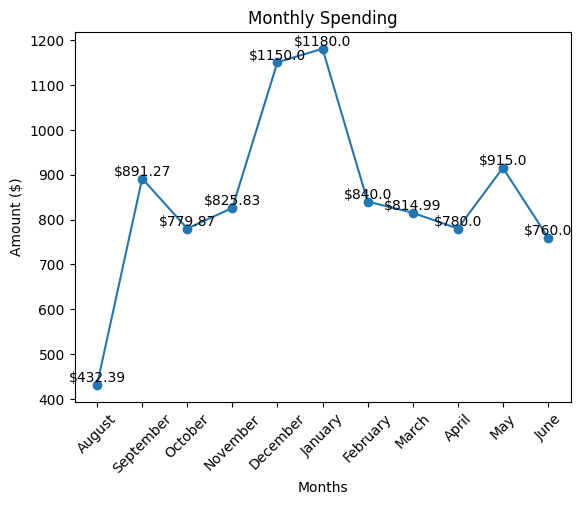

In [31]:
plt.plot(range(len(monthly_totals)),monthly_totals.values,marker='o')

plt.title('Monthly Spending')
plt.xlabel('Months')
plt.ylabel('Amount ($)')

plt.xticks(range(len(monthly_totals)), ['August','September','October','November','December','January','February','March','April','May','June'],rotation=45)

for month,amount,label in zip(range(len(monthly_totals)),monthly_totals.values,labels):
    plt.text(month,amount,label,ha='center',va='bottom')
plt.show()

ML MODEL TO PREDICT TOTAL SPENDINH FOR THE NEXT MONTH

In [32]:
print(df.head())
print(df.info())

        Date        Category           Description  Amount  Month
0 2026-08-07  Transportation                  Lyft   24.78      8
1 2026-08-15            Food              Ubereats   25.41      8
2 2026-08-03   Entertainment              Cineplex   16.00      8
3 2026-08-04   Entertainment  Netflix subscription   24.54      8
4 2026-08-10        Shopping         Personal care   55.00      8
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         60 non-null     datetime64[us]
 1   Category     60 non-null     str           
 2   Description  60 non-null     str           
 3   Amount       60 non-null     float64       
 4   Month        60 non-null     int32         
dtypes: datetime64[us](1), float64(1), int32(1), str(2)
memory usage: 2.2 KB
None


In [33]:
print(df.columns)

Index(['Date', 'Category', 'Description', 'Amount', 'Month'], dtype='str')


In [34]:
month_order = [8,9,10,11,12,1,2,3,4,5,6]

monthly_data = df.groupby('Month')['Amount'].sum().reset_index()

monthly_data = monthly_data.set_index('Month').loc[month_order].reset_index()

print(monthly_data)

    Month   Amount
0       8   432.39
1       9   891.27
2      10   779.87
3      11   825.83
4      12  1150.00
5       1  1180.00
6       2   840.00
7       3   814.99
8       4   780.00
9       5   915.00
10      6   760.00


In [35]:
monthly_data['Previous_Month'] = monthly_data['Amount'].shift(1)

In [36]:
monthly_data = monthly_data.dropna()

monthly_data

,Month,Amount,Previous_Month
1,9,891.27,432.39
2,10,779.87,891.27
3,11,825.83,779.87
4,12,1150.00,825.83
5,1,1180.00,1150.00
6,2,840.00,1180.00
7,3,814.99,840.00
8,4,780.00,814.99
9,5,915.00,780.00
10,6,760.00,915.00


In [37]:
x = monthly_data[['Previous_Month']]
y = monthly_data['Amount']

print(x)
print(y)

    Previous_Month
1           432.39
2           891.27
3           779.87
4           825.83
5          1150.00
6          1180.00
7           840.00
8           814.99
9           780.00
10          915.00
1      891.27
2      779.87
3      825.83
4     1150.00
5     1180.00
6      840.00
7      814.99
8      780.00
9      915.00
10     760.00
Name: Amount, dtype: float64


In [38]:
x_train = x.iloc[:8]
x_test = x.iloc[8:]

y_train = y.iloc[:8]
y_test = y.iloc[8:]

print(x_train)
print(x_test)
print(y_train)
print(y_test)

   Previous_Month
1          432.39
2          891.27
3          779.87
4          825.83
5         1150.00
6         1180.00
7          840.00
8          814.99
    Previous_Month
9            780.0
10           915.0
1     891.27
2     779.87
3     825.83
4    1150.00
5    1180.00
6     840.00
7     814.99
8     780.00
Name: Amount, dtype: float64
9     915.0
10    760.0
Name: Amount, dtype: float64


In [39]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
print(model.coef_)
print(model.intercept_)

[0.17415453]
757.2243273602301


In [41]:
predictions = model.predict(x_test)

print(predictions)

[893.06486151 916.57572319]


In [42]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,predictions)

print(mae)

89.25543083955478


ML MODEL TO PREDICT EACH CATEGORY SPENDING FOR THE NEXT MONTH

In [43]:
category_data = df.groupby(['Month','Category'])['Amount'].sum().reset_index()

category_data['Month'] = pd.Categorical(
    category_data['Month'],
    categories=month_order,
    ordered=True
)

category_data = category_data.sort_values('Month')
print(category_data)

   Month        Category  Amount
25     8   Entertainment   40.54
27     8          School   50.00
28     8        Shopping  155.21
29     8  Transportation   91.23
26     8            Food   95.41
30     9            Food  100.59
31     9            Rent  600.00
32     9          School   90.00
33     9        Shopping   50.68
34     9       Utilities   50.00
35    10            Food   55.00
36    10            Rent  600.00
37    10          School    5.59
39    10  Transportation   10.49
40    10       Utilities   70.00
38    10        Shopping   38.79
41    11   Entertainment   45.00
42    11            Rent  600.00
43    11        Shopping  100.00
44    11  Transportation   20.83
45    11       Utilities   60.00
46    12   Entertainment  100.00
47    12            Food  200.00
48    12            Rent  600.00
49    12        Shopping  200.00
50    12       Utilities   50.00
0      1            Food  150.00
1      1            Rent  600.00
2      1          School   40.00
3      1  

In [49]:
category_monthly = df.groupby(["Month","Category"])["Amount"].sum().reset_index()

category_monthly = category_monthly.set_index("Month").loc[month_order].reset_index()

print(category_monthly)

    Month        Category  Amount
0       8   Entertainment   40.54
1       8            Food   95.41
2       8          School   50.00
3       8        Shopping  155.21
4       8  Transportation   91.23
5       9            Food  100.59
6       9            Rent  600.00
7       9          School   90.00
8       9        Shopping   50.68
9       9       Utilities   50.00
10     10            Food   55.00
11     10            Rent  600.00
12     10          School    5.59
13     10        Shopping   38.79
14     10  Transportation   10.49
15     10       Utilities   70.00
16     11   Entertainment   45.00
17     11            Rent  600.00
18     11        Shopping  100.00
19     11  Transportation   20.83
20     11       Utilities   60.00
21     12   Entertainment  100.00
22     12            Food  200.00
23     12            Rent  600.00
24     12        Shopping  200.00
25     12       Utilities   50.00
26      1            Food  150.00
27      1            Rent  600.00
28      1     

In [52]:
months = category_monthly["Month"].unique()
categories = category_monthly["Category"].unique()

print(months)
print(categories)

[ 8  9 10 11 12  1  2  3  4  5  6]
<StringArray>
[ 'Entertainment',           'Food',         'School',       'Shopping',
 'Transportation',           'Rent',      'Utilities']
Length: 7, dtype: str


In [54]:
all_combinations = pd.MultiIndex.from_product(
    [months,categories],
    names=["Month","Category"]
)

category_monthly = category_monthly.set_index(
    ["Month","Category"]
).reindex(all_combinations).reset_index()

print(category_monthly)

    Month        Category  Amount  Previous_Month
0       8   Entertainment   40.54             NaN
1       8            Food   95.41             NaN
2       8          School   50.00             NaN
3       8        Shopping  155.21             NaN
4       8  Transportation   91.23             NaN
..    ...             ...     ...             ...
72      6          School     NaN             NaN
73      6        Shopping     NaN             NaN
74      6  Transportation   35.00           235.0
75      6            Rent  600.00           600.0
76      6       Utilities   50.00            40.0

[77 rows x 4 columns]


In [60]:
category_monthly["Amount"] = category_monthly["Amount"].fillna(0)

category_monthly["Previous_Month"] = category_monthly.groupby("Category")["Amount"].shift(1)

category_monthly = category_monthly.dropna(subset=["Previous_Month"])

category_monthly

,Month,Category,Amount,Previous_Month
7,9,Entertainment,0.00,40.54
8,9,Food,100.59,95.41
9,9,School,90.00,50.00
10,9,Shopping,50.68,155.21
11,9,Transportation,0.00,91.23
...,...,...,...,...
72,6,School,0.00,0.00
73,6,Shopping,0.00,40.00
74,6,Transportation,35.00,235.00
75,6,Rent,600.00,600.00


In [64]:
category_encoded = pd.get_dummies(category_monthly["Category"])

x = pd.concat(
    [category_monthly["Previous_Month"],category_encoded],
    axis=1
)

y = category_monthly["Amount"]

x.head()

,Previous_Month,Entertainment,Food,Rent,School,Shopping,Transportation,Utilities
7,40.54,True,False,False,False,False,False,False
8,95.41,False,True,False,False,False,False,False
9,50.00,False,False,False,True,False,False,False
10,155.21,False,False,False,False,True,False,False
11,91.23,False,False,False,False,False,True,False


In [71]:
x_cat_train = x.iloc[:42]
x_cat_test = x.iloc[42:]

y_cat_train = y.iloc[:42]
y_cat_test = y.iloc[42:]

print(x_cat_train.shape)
print(x_cat_test.shape)

print(y_cat_train.shape)
print(y_cat_test.shape)

(42, 8)
(28, 8)
(42,)
(28,)


In [72]:
from sklearn.tree import DecisionTreeRegressor

In [74]:
category_model = DecisionTreeRegressor(random_state=42)

category_model.fit(x_cat_train,y_cat_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [76]:
y_cat_pred = category_model.predict(x_cat_test)

print(y_cat_pred)

[ 15.    200.     20.     50.68    0.    600.     50.    100.     55.
  20.    150.    180.245 600.     60.      5.59  200.     20.     38.79
 180.245 600.     60.     15.    200.     20.    100.     30.    600.
  60.   ]


In [77]:
comparison = pd.DataFrame({
    "Actual": y_cat_test.values,
    "Predicted": y_cat_pred
})

comparison

,Actual,Predicted
0,44.99,15.000
1,100.00,200.000
2,0.00,20.000
3,0.00,50.680
4,0.00,0.000
5,600.00,600.000
6,70.00,50.000
7,60.00,100.000
8,0.00,55.000
9,0.00,20.000


In [78]:
mean_absolute_error(y_cat_test, y_cat_pred)

47.23107142857143

In [79]:
from sklearn.metrics import r2_score

r2 = r2_score(y_cat_test, y_cat_pred)
print(r2)

0.8614705654324737


In [80]:
comparison["Category"] = category_monthly["Category"].iloc[42:].values

comparison

,Actual,Predicted,Category
0,44.99,15.000,Entertainment
1,100.00,200.000,Food
2,0.00,20.000,School
3,0.00,50.680,Shopping
4,0.00,0.000,Transportation
5,600.00,600.000,Rent
6,70.00,50.000,Utilities
7,60.00,100.000,Entertainment
8,0.00,55.000,Food
9,0.00,20.000,School
